# 71 — Unified model comparison (paper-facing)

Single entry point for the **benchmark bundle** spanning four evaluation axes:

- **Standard fairness** — accuracy, macro-F1, robust TPR gaps from saved `training_config.json`, aligned with the standard test track.
- **City-swap** — counterfactual-city stability (`overall_flip_rate` from archived batch JSON / merged challenger run-level swap CSV when present): one robustness axis among several, not the only stress test.
- **Adversarial eval** — minimal-edit resume pairs (flip rate on anchor vs counterfactual from `notebooks/results/adversarial_model_eval/<model_run_id>/metrics.json` when available).
- **English transfer** — held-out English splits / slices from `notebooks/results/english_transfer_eval/<model_run_id>/metrics.json` when available (headline: `english_test` macro-F1 and accuracy; optional `english_base_eval_slice` columns when logged).

**Rules:** no training, no long re-evaluations, no new city-swap runs. Load existing JSON/CSV/config only.

Legacy `c71_*` filenames are still written; numbered `01_*`…`08_*` files are the primary **paper bundle**.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
except ImportError:
    plt = None
    mpatches = None

try:
    import seaborn as sns
except ImportError:
    sns = None


In [2]:
CWD = Path.cwd().resolve()
NOTEBOOKS_DIR = CWD.parent if CWD.name == "challengers" else CWD
PROJECT_ROOT = NOTEBOOKS_DIR.parent
NOTEBOOK_RESULTS_DIR = PROJECT_ROOT / 'notebooks' / 'results'
FIGURES_DIR = PROJECT_ROOT / 'figures'
CHALLENGER_FIGURES_DIR = FIGURES_DIR / 'challengers'
OUTPUT_DIR = NOTEBOOK_RESULTS_DIR / 'unified_comparison'
FIGURES_UNIFIED = FIGURES_DIR / 'unified_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_UNIFIED.mkdir(parents=True, exist_ok=True)

MAIN_CITY_SWAP_JSON_CANDIDATES = [
    NOTEBOOK_RESULTS_DIR / 'city_swap_all' / 'city_swap_all_models.json',
    FIGURES_DIR / 'city_swap_all' / 'city_swap_all_models.json',
    PROJECT_ROOT / 'results' / 'city_swap_all' / 'city_swap_all_models.json',
]
CHALLENGER_OVERVIEW_CSV = CHALLENGER_FIGURES_DIR / 'c00_all_models_overview.csv'
CHALLENGER_MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / 'notebooks' / 'models' / 'challengers',
    PROJECT_ROOT / 'models' / 'challengers',
]
CHALLENGER_CITY_SWAP_RUN_CANDIDATES = [
    NOTEBOOK_RESULTS_DIR / 'challengers_city_swap' / 'c10_city_swap_run_level.csv',
    CHALLENGER_FIGURES_DIR / 'c10_city_swap_run_level.csv',
    PROJECT_ROOT / 'results' / 'challengers_city_swap' / 'c10_city_swap_run_level.csv',
]
CHALLENGER_CITY_SWAP_FAMILY_CANDIDATES = [
    NOTEBOOK_RESULTS_DIR / 'challengers_city_swap' / 'c10_city_swap_family_level.csv',
    CHALLENGER_FIGURES_DIR / 'c10_city_swap_family_level.csv',
    PROJECT_ROOT / 'results' / 'challengers_city_swap' / 'c10_city_swap_family_level.csv',
]
FAIRNESS_MAIN_METRICS_CSV = NOTEBOOK_RESULTS_DIR / 'fairness_error_analysis' / '01_main_model_fairness_metrics.csv'

TEXT_REPORT = OUTPUT_DIR / 'c71_unified_models_report.txt'
TABLE_CSV = OUTPUT_DIR / 'c71_unified_models_table.csv'
TABLE_PRIMARY = OUTPUT_DIR / '01_unified_models_full_table.csv'
MAIN_TABLE_OUT = OUTPUT_DIR / '02_main_track_models.csv'
CHALLENGER_TABLE_OUT = OUTPUT_DIR / '03_challenger_track_models.csv'
RANK_PICKS_CSV = OUTPUT_DIR / '04_ranking_picks_by_scope.csv'
PARETO_CSV = OUTPUT_DIR / '05_pareto_triobjective_balance.csv'
FAMILY_CSV = OUTPUT_DIR / 'c71_family_summary.csv'
FAMILY_RICH_CSV = OUTPUT_DIR / '06_family_best_per_metric.csv'
PLOT_LEGACY = OUTPUT_DIR / 'c71_accuracy_vs_gap.png'
FIG_ACC_GAP = FIGURES_UNIFIED / 'fig01_accuracy_vs_worst_gap.png'
FIG_F1_FLIP = FIGURES_UNIFIED / 'fig02_macro_f1_vs_city_swap_flip.png'
FIG_MAIN_BARS = FIGURES_UNIFIED / 'fig03_main_models_three_metrics.png'
FIG_F1_ADV_FLIP = FIGURES_UNIFIED / 'fig04_macro_f1_vs_adversarial_pair_flip.png'

PARETO_EXTENDED_CSV = OUTPUT_DIR / '05_pareto_extended_benchmark_balance.csv'


def first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None


MAIN_CITY_SWAP_JSON = first_existing(MAIN_CITY_SWAP_JSON_CANDIDATES)
CHALLENGER_CITY_SWAP_RUN_CSV = first_existing(CHALLENGER_CITY_SWAP_RUN_CANDIDATES)
CHALLENGER_CITY_SWAP_FAMILY_CSV = first_existing(CHALLENGER_CITY_SWAP_FAMILY_CANDIDATES)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('MAIN_CITY_SWAP_JSON:', MAIN_CITY_SWAP_JSON)
print('CHALLENGER_OVERVIEW_CSV exists:', CHALLENGER_OVERVIEW_CSV.exists())
print('CHALLENGER_CITY_SWAP_RUN_CSV:', CHALLENGER_CITY_SWAP_RUN_CSV)
print('CHALLENGER_CITY_SWAP_FAMILY_CSV:', CHALLENGER_CITY_SWAP_FAMILY_CSV)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('FIGURES_UNIFIED:', FIGURES_UNIFIED)


PROJECT_ROOT: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
MAIN_CITY_SWAP_JSON: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/city_swap_all/city_swap_all_models.json
CHALLENGER_OVERVIEW_CSV exists: True
CHALLENGER_CITY_SWAP_RUN_CSV: None
CHALLENGER_CITY_SWAP_FAMILY_CSV: None
OUTPUT_DIR: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/unified_comparison
FIGURES_UNIFIED: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/unified_comparison


In [3]:
MAIN_MODEL_REGISTRY = [
    {'legacy_key': '1_baseline', 'model_dir': 'bert_9classes_final', 'display_name': 'Baseline', 'family_group': 'baseline', 'track': 'main', 'method_group': 'baseline'},
    {'legacy_key': '2_groupdro', 'model_dir': 'bert_gdro_eta01_2ep', 'display_name': 'GroupDRO η=0.1', 'family_group': 'groupdro', 'track': 'main', 'method_group': 'groupdro'},
    {'legacy_key': '3_scrubbing', 'model_dir': 'bert_scrubbing', 'display_name': 'Data Scrubbing', 'family_group': 'scrubbing', 'track': 'main', 'method_group': 'scrubbing'},
    {'legacy_key': '4_oversampling', 'model_dir': 'bert_oversample_only', 'display_name': 'Oversampling', 'family_group': 'oversampling', 'track': 'main', 'method_group': 'oversampling'},
    {'legacy_key': '5_focal_loss', 'model_dir': 'bert_focal_loss', 'display_name': 'Focal Loss', 'family_group': 'focal', 'track': 'main', 'method_group': 'focal'},
    {'legacy_key': '6_adversarial', 'model_dir': 'bert_adversarial', 'display_name': 'Adversarial Debiasing', 'family_group': 'adversarial', 'track': 'main', 'method_group': 'adversarial'},
    {'legacy_key': '7_label_smoothing', 'model_dir': 'bert_label_smoothing', 'display_name': 'Label Smoothing', 'family_group': 'label_smoothing', 'track': 'main', 'method_group': 'label_smoothing'},
    {'legacy_key': '8_attribution_reg', 'model_dir': 'bert_attr_reg', 'display_name': 'Attribution Regularization', 'family_group': 'attr_reg', 'track': 'main', 'method_group': 'attr_reg'},
    {'legacy_key': '9_combined_scrub_gdro', 'model_dir': 'bert_debiased_combo', 'display_name': 'Combined Scrub + GroupDRO', 'family_group': 'combined', 'track': 'main', 'method_group': 'combined'},
    {'legacy_key': '10_combined_best', 'model_dir': 'combined_scrubbing_groupdro', 'display_name': 'Combined Best', 'family_group': 'combined', 'track': 'main', 'method_group': 'combined'},
]

FAMILY_ORDER = {
    'baseline': 0,
    'groupdro': 1,
    'focal': 2,
    'label_smoothing': 3,
    'adversarial': 4,
    'scrubbing': 5,
    'attr_reg': 6,
    'oversampling': 7,
    'combined': 8,
    'weighted_sampler': 9,
    'rdrop': 10,
    'class_balanced': 11,
    'logit_adjustment': 12,
    'other': 99,
}

TRACK_ORDER = {'main': 0, 'challenger': 1}


In [4]:
def _safe_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def normalize_family_group(model_dir, method_group):
    model_dir = str(model_dir or '')
    method_group = str(method_group or '')
    if method_group in FAMILY_ORDER:
        return method_group
    if 'gdro' in model_dir:
        return 'groupdro'
    if 'focal' in model_dir:
        return 'focal'
    if 'label_smoothing' in model_dir or 'ls_' in model_dir:
        return 'label_smoothing'
    if 'rdrop' in model_dir:
        return 'rdrop'
    if 'weighted_sampler' in model_dir:
        return 'weighted_sampler'
    if 'class_balanced' in model_dir:
        return 'class_balanced'
    if 'logit_adjustment' in model_dir:
        return 'logit_adjustment'
    return 'other'


def load_main_rows():
    if MAIN_CITY_SWAP_JSON is None:
        raise FileNotFoundError('Main city-swap JSON not found')
    data = json.loads(MAIN_CITY_SWAP_JSON.read_text())
    rows = []
    for meta in MAIN_MODEL_REGISTRY:
        res = data.get(meta['legacy_key'], {})
        rows.append({
            'track': meta['track'],
            'family_group': meta['family_group'],
            'method_group': meta['method_group'],
            'source_block': 'main',
            'model_name': meta['model_dir'],
            'display_name': meta['display_name'],
            'method': meta['display_name'],
            'seed': np.nan,
            'accuracy': _safe_float(res.get('accuracy')),
            'macro_f1': _safe_float(res.get('macro_f1')),
            'worst_gap': np.nan,
            'macro_gap': np.nan,
            'overall_flip_rate': _safe_float(res.get('overall_flip_rate')),
            'model_dir': res.get('model_dir', meta['model_dir']),
            'summary_source': str(MAIN_CITY_SWAP_JSON.relative_to(PROJECT_ROOT)) if MAIN_CITY_SWAP_JSON else '',
        })
    return pd.DataFrame(rows)


def resolve_challenger_model_dir(model_dir, model_name):
    model_dir = str(model_dir or '').strip()
    direct_candidates = []
    if model_dir:
        direct_candidates.append(PROJECT_ROOT / model_dir)
        if model_dir.startswith('models/challengers/'):
            alt_model_dir = model_dir.replace('models/challengers/', 'notebooks/models/challengers/', 1)
            direct_candidates.append(PROJECT_ROOT / alt_model_dir)
        elif model_dir.startswith('notebooks/models/challengers/'):
            alt_model_dir = model_dir.replace('notebooks/models/challengers/', 'models/challengers/', 1)
            direct_candidates.append(PROJECT_ROOT / alt_model_dir)

    for candidate in direct_candidates:
        if candidate.exists():
            return str(candidate.relative_to(PROJECT_ROOT))

    for root in CHALLENGER_MODEL_DIR_CANDIDATES:
        candidate = root / model_name
        if candidate.exists():
            return str(candidate.relative_to(PROJECT_ROOT))

    return model_dir


def load_challenger_rows():
    if not CHALLENGER_OVERVIEW_CSV.exists():
        raise FileNotFoundError('c00_all_models_overview.csv not found')
    df = pd.read_csv(CHALLENGER_OVERVIEW_CSV)
    df = df.copy()
    df['track'] = 'challenger'
    df['source_block'] = 'challenger'
    df['display_name'] = df['model_name']
    df['model_dir'] = [resolve_challenger_model_dir(md, mn) for md, mn in zip(df['model_dir'], df['model_name'])]
    df['family_group'] = [normalize_family_group(md, mg) for md, mg in zip(df['model_dir'], df['method_group'])]
    if 'seed' not in df.columns:
        df['seed'] = np.nan
    return df[['track', 'family_group', 'method_group', 'source_block', 'model_name', 'display_name', 'method', 'seed', 'accuracy', 'macro_f1', 'worst_gap', 'macro_gap', 'overall_flip_rate', 'model_dir', 'summary_source']].copy()


In [5]:
main_df = load_main_rows()
challenger_df = load_challenger_rows()

print('main rows:', len(main_df))
print('challenger rows:', len(challenger_df))
display(main_df)
display(challenger_df.head(20))


main rows: 10
challenger rows: 29


,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,model_dir,summary_source
0,main,baseline,baseline,main,bert_9classes_final,Baseline,Baseline,NaN,0.608530,0.620627,NaN,NaN,0.077132,bert_9classes_final,notebooks/results/city_swap_all/city_swap_all_...
1,main,groupdro,groupdro,main,bert_gdro_eta01_2ep,GroupDRO η=0.1,GroupDRO η=0.1,NaN,0.547731,0.552506,NaN,NaN,0.115789,bert_gdro_eta01_2ep,notebooks/results/city_swap_all/city_swap_all_...
2,main,scrubbing,scrubbing,main,bert_scrubbing,Data Scrubbing,Data Scrubbing,NaN,0.594192,0.610640,NaN,NaN,0.000000,bert_scrubbing,notebooks/results/city_swap_all/city_swap_all_...
3,main,oversampling,oversampling,main,bert_oversample_only,Oversampling,Oversampling,NaN,0.600544,0.611463,NaN,NaN,0.100363,bert_oversample_only,notebooks/results/city_swap_all/city_swap_all_...
4,main,focal,focal,main,bert_focal_loss,Focal Loss,Focal Loss,NaN,0.592559,0.613432,NaN,NaN,0.068966,bert_focal_loss,notebooks/results/city_swap_all/city_swap_all_...
5,main,adversarial,adversarial,main,bert_adversarial,Adversarial Debiasing,Adversarial Debiasing,NaN,NaN,NaN,NaN,NaN,NaN,bert_adversarial,notebooks/results/city_swap_all/city_swap_all_...
6,main,label_smoothing,label_smoothing,main,bert_label_smoothing,Label Smoothing,Label Smoothing,NaN,0.596189,0.608055,NaN,NaN,0.107260,bert_label_smoothing,notebooks/results/city_swap_all/city_swap_all_...
7,main,attr_reg,attr_reg,main,bert_attr_reg,Attribution Regularization,Attribution Regularization,NaN,NaN,NaN,NaN,NaN,NaN,bert_attr_reg,notebooks/results/city_swap_all/city_swap_all_...
8,main,combined,combined,main,bert_debiased_combo,Combined Scrub + GroupDRO,Combined Scrub + GroupDRO,NaN,0.486570,0.475259,NaN,NaN,0.000000,bert_debiased_combo,notebooks/results/city_swap_all/city_swap_all_...
9,main,combined,combined,main,combined_scrubbing_groupdro,Combined Best,Combined Best,NaN,0.576407,0.597117,NaN,NaN,0.000000,combined_scrubbing_groupdro,notebooks/results/city_swap_all/city_swap_all_...


,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,model_dir,summary_source
0,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps01_2ep,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,NaN,0.608348,0.622958,0.317647,0.135788,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...
1,challenger,class_balanced,class_balanced,challenger,class_balanced_cbce_beta099_2ep,class_balanced_cbce_beta099_2ep,Class-Balanced CE + sqrt_rw,NaN,0.606897,0.620787,0.388235,0.137249,NaN,notebooks/models/challengers/class_balanced_cb...,figures/challengers/c04_class_balanced_tuning_...
2,challenger,rdrop,rdrop,challenger,rdrop_alpha20_2ep,rdrop_alpha20_2ep,R-Drop + sqrt_rw,NaN,0.604174,0.620712,0.335294,0.137523,NaN,notebooks/models/challengers/rdrop_alpha20_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
3,challenger,rdrop,rdrop,challenger,rdrop_alpha10_2ep,rdrop_alpha10_2ep,R-Drop + sqrt_rw,NaN,0.606715,0.620074,0.311765,0.126811,NaN,notebooks/models/challengers/rdrop_alpha10_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
4,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps005_2ep,label_smoothing_eps005_2ep,Label Smoothing + sqrt_rw,NaN,0.605263,0.619809,0.323529,0.127693,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...
5,challenger,focal,focal,challenger,focal_gamma1_2ep,focal_gamma1_2ep,Focal Loss + sqrt_rw,NaN,0.604174,0.619110,0.323529,0.133677,NaN,notebooks/models/challengers/focal_gamma1_2ep,figures/challengers/c02_focal_tuning_summary.csv
6,challenger,rdrop,rdrop,challenger,rdrop_alpha05_2ep,rdrop_alpha05_2ep,R-Drop + sqrt_rw,NaN,0.605626,0.618289,0.329412,0.115698,NaN,notebooks/models/challengers/rdrop_alpha05_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
7,challenger,logit_adjustment,logit_adjustment,challenger,logit_adjustment_tau05_2ep,logit_adjustment_tau05_2ep,Logit Adjustment + sqrt_rw,NaN,0.598911,0.617222,0.370588,0.125859,NaN,notebooks/models/challengers/logit_adjustment_...,figures/challengers/c05_logit_adjustment_tunin...
8,challenger,focal,focal,challenger,focal_gamma3_2ep,focal_gamma3_2ep,Focal Loss + sqrt_rw,NaN,0.600363,0.617063,0.347059,0.142573,NaN,notebooks/models/challengers/focal_gamma3_2ep,figures/challengers/c02_focal_tuning_summary.csv
9,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps015_2ep,label_smoothing_eps015_2ep,Label Smoothing + sqrt_rw,NaN,0.599456,0.615785,0.341176,0.141312,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...


In [6]:
# Attach robust fairness metrics for main models from training configs when available
MODEL_DIR_ROOTS = [
    PROJECT_ROOT / 'notebooks' / 'models',
    PROJECT_ROOT / 'models',
    PROJECT_ROOT.parent / 'notebooks' / 'models',
    PROJECT_ROOT.parent / 'models',
]

def resolve_training_config(model_dir_name):
    for root in MODEL_DIR_ROOTS:
        cfg = root / model_dir_name / 'training_config.json'
        if cfg.exists():
            return cfg
    return None

main_cfg_rows = []
for _, row in main_df.iterrows():
    cfg_path = resolve_training_config(row['model_name'])
    rec = {'model_name': row['model_name'], 'config_path': str(cfg_path) if cfg_path else ''}
    if cfg_path is not None:
        cfg = json.loads(cfg_path.read_text())
        rec['accuracy_cfg'] = _safe_float(cfg.get('accuracy'))
        rec['macro_f1_cfg'] = _safe_float(cfg.get('macro_f1'))
        rec['worst_gap_cfg'] = _safe_float(cfg.get('tpr_gap_worst_robust', cfg.get('tpr_gap_worst')) )
        rec['macro_gap_cfg'] = _safe_float(cfg.get('tpr_gap_macro_robust', cfg.get('tpr_gap_macro')) )
        rec['method_cfg'] = cfg.get('method')
    else:
        rec['accuracy_cfg'] = np.nan
        rec['macro_f1_cfg'] = np.nan
        rec['worst_gap_cfg'] = np.nan
        rec['macro_gap_cfg'] = np.nan
        rec['method_cfg'] = ''
    main_cfg_rows.append(rec)

main_cfg_df = pd.DataFrame(main_cfg_rows)
main_df = main_df.merge(main_cfg_df, on='model_name', how='left')
main_df['accuracy'] = main_df['accuracy_cfg'].combine_first(main_df['accuracy'])
main_df['macro_f1'] = main_df['macro_f1_cfg'].combine_first(main_df['macro_f1'])
main_df['worst_gap'] = main_df['worst_gap_cfg'].combine_first(main_df['worst_gap'])
main_df['macro_gap'] = main_df['macro_gap_cfg'].combine_first(main_df['macro_gap'])
main_df['method'] = main_df['method_cfg'].replace('', np.nan).combine_first(main_df['method'])
main_df = main_df[['track', 'family_group', 'method_group', 'source_block', 'model_name', 'display_name', 'method', 'seed', 'accuracy', 'macro_f1', 'worst_gap', 'macro_gap', 'overall_flip_rate', 'model_dir', 'summary_source']]
display(main_cfg_df)
display(main_df)


,model_name,config_path,accuracy_cfg,macro_f1_cfg,worst_gap_cfg,macro_gap_cfg,method_cfg
0,bert_9classes_final,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.609000,0.621000,0.329000,0.116000,Baseline BERT + sqrt_rw
1,bert_gdro_eta01_2ep,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.547731,0.552506,0.264706,0.112955,"GroupDRO eta=0.1 + sqrt_rw, 2ep"
2,bert_scrubbing,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.594192,0.610567,0.300000,0.112077,Data Scrubbing + sqrt_rw
3,bert_oversample_only,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.600544,0.611463,0.358333,0.134891,oversampling + sqrt_reweight (NO GroupDRO)
4,bert_focal_loss,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.592559,0.613432,0.329412,0.135682,Focal Loss gamma=2.0 + sqrt_rw
5,bert_adversarial,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.574410,0.594231,0.429412,0.131834,Adversarial Debiasing α=0.5 + sqrt_rw
6,bert_label_smoothing,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.596189,0.608055,0.329412,0.139537,Label Smoothing ε=0.1 + sqrt_rw
7,bert_attr_reg,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.583303,0.601165,0.335294,0.116298,Attribution Regularization (attention) λ=0.1 +...
8,bert_debiased_combo,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.488203,0.480776,0.405882,0.137764,sqrt_reweight + oversampling + GroupDRO
9,combined_scrubbing_groupdro,,NaN,NaN,NaN,NaN,


,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,model_dir,summary_source
0,main,baseline,baseline,main,bert_9classes_final,Baseline,Baseline BERT + sqrt_rw,NaN,0.609000,0.621000,0.329000,0.116000,0.077132,bert_9classes_final,notebooks/results/city_swap_all/city_swap_all_...
1,main,groupdro,groupdro,main,bert_gdro_eta01_2ep,GroupDRO η=0.1,"GroupDRO eta=0.1 + sqrt_rw, 2ep",NaN,0.547731,0.552506,0.264706,0.112955,0.115789,bert_gdro_eta01_2ep,notebooks/results/city_swap_all/city_swap_all_...
2,main,scrubbing,scrubbing,main,bert_scrubbing,Data Scrubbing,Data Scrubbing + sqrt_rw,NaN,0.594192,0.610567,0.300000,0.112077,0.000000,bert_scrubbing,notebooks/results/city_swap_all/city_swap_all_...
3,main,oversampling,oversampling,main,bert_oversample_only,Oversampling,oversampling + sqrt_reweight (NO GroupDRO),NaN,0.600544,0.611463,0.358333,0.134891,0.100363,bert_oversample_only,notebooks/results/city_swap_all/city_swap_all_...
4,main,focal,focal,main,bert_focal_loss,Focal Loss,Focal Loss gamma=2.0 + sqrt_rw,NaN,0.592559,0.613432,0.329412,0.135682,0.068966,bert_focal_loss,notebooks/results/city_swap_all/city_swap_all_...
5,main,adversarial,adversarial,main,bert_adversarial,Adversarial Debiasing,Adversarial Debiasing α=0.5 + sqrt_rw,NaN,0.574410,0.594231,0.429412,0.131834,NaN,bert_adversarial,notebooks/results/city_swap_all/city_swap_all_...
6,main,label_smoothing,label_smoothing,main,bert_label_smoothing,Label Smoothing,Label Smoothing ε=0.1 + sqrt_rw,NaN,0.596189,0.608055,0.329412,0.139537,0.107260,bert_label_smoothing,notebooks/results/city_swap_all/city_swap_all_...
7,main,attr_reg,attr_reg,main,bert_attr_reg,Attribution Regularization,Attribution Regularization (attention) λ=0.1 +...,NaN,0.583303,0.601165,0.335294,0.116298,NaN,bert_attr_reg,notebooks/results/city_swap_all/city_swap_all_...
8,main,combined,combined,main,bert_debiased_combo,Combined Scrub + GroupDRO,sqrt_reweight + oversampling + GroupDRO,NaN,0.488203,0.480776,0.405882,0.137764,0.000000,bert_debiased_combo,notebooks/results/city_swap_all/city_swap_all_...
9,main,combined,combined,main,combined_scrubbing_groupdro,Combined Best,Combined Best,NaN,0.576407,0.597117,NaN,NaN,0.000000,combined_scrubbing_groupdro,notebooks/results/city_swap_all/city_swap_all_...


In [7]:
# Optionally merge challenger city-swap run-level results if they already exist,
# but proceed safely if CHALLENGER_CITY_SWAP_RUN_CSV is None
if CHALLENGER_CITY_SWAP_RUN_CSV is not None and getattr(CHALLENGER_CITY_SWAP_RUN_CSV, "exists", lambda: False)():
    c10_run_df = pd.read_csv(CHALLENGER_CITY_SWAP_RUN_CSV)
    merge_cols = ['model_name', 'overall_flip_rate'] + [c for c in c10_run_df.columns if c.startswith('flip_')]
    c10_run_df = c10_run_df[merge_cols].copy()
    challenger_df = challenger_df.drop(columns=['overall_flip_rate'], errors='ignore').merge(c10_run_df, on='model_name', how='left')

display(challenger_df.head(20))


,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,model_dir,summary_source
0,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps01_2ep,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,NaN,0.608348,0.622958,0.317647,0.135788,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...
1,challenger,class_balanced,class_balanced,challenger,class_balanced_cbce_beta099_2ep,class_balanced_cbce_beta099_2ep,Class-Balanced CE + sqrt_rw,NaN,0.606897,0.620787,0.388235,0.137249,NaN,notebooks/models/challengers/class_balanced_cb...,figures/challengers/c04_class_balanced_tuning_...
2,challenger,rdrop,rdrop,challenger,rdrop_alpha20_2ep,rdrop_alpha20_2ep,R-Drop + sqrt_rw,NaN,0.604174,0.620712,0.335294,0.137523,NaN,notebooks/models/challengers/rdrop_alpha20_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
3,challenger,rdrop,rdrop,challenger,rdrop_alpha10_2ep,rdrop_alpha10_2ep,R-Drop + sqrt_rw,NaN,0.606715,0.620074,0.311765,0.126811,NaN,notebooks/models/challengers/rdrop_alpha10_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
4,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps005_2ep,label_smoothing_eps005_2ep,Label Smoothing + sqrt_rw,NaN,0.605263,0.619809,0.323529,0.127693,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...
5,challenger,focal,focal,challenger,focal_gamma1_2ep,focal_gamma1_2ep,Focal Loss + sqrt_rw,NaN,0.604174,0.619110,0.323529,0.133677,NaN,notebooks/models/challengers/focal_gamma1_2ep,figures/challengers/c02_focal_tuning_summary.csv
6,challenger,rdrop,rdrop,challenger,rdrop_alpha05_2ep,rdrop_alpha05_2ep,R-Drop + sqrt_rw,NaN,0.605626,0.618289,0.329412,0.115698,NaN,notebooks/models/challengers/rdrop_alpha05_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
7,challenger,logit_adjustment,logit_adjustment,challenger,logit_adjustment_tau05_2ep,logit_adjustment_tau05_2ep,Logit Adjustment + sqrt_rw,NaN,0.598911,0.617222,0.370588,0.125859,NaN,notebooks/models/challengers/logit_adjustment_...,figures/challengers/c05_logit_adjustment_tunin...
8,challenger,focal,focal,challenger,focal_gamma3_2ep,focal_gamma3_2ep,Focal Loss + sqrt_rw,NaN,0.600363,0.617063,0.347059,0.142573,NaN,notebooks/models/challengers/focal_gamma3_2ep,figures/challengers/c02_focal_tuning_summary.csv
9,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps015_2ep,label_smoothing_eps015_2ep,Label Smoothing + sqrt_rw,NaN,0.599456,0.615785,0.341176,0.141312,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...


In [8]:
def collect_adversarial_and_transfer_axes(nb_results: Path) -> pd.DataFrame:
    """Merge per-artifact-folder metrics from adversarial_model_eval (58) and english_transfer_eval (59); folder name matches `model_name` / model_run_id."""
    adv_root = nb_results / 'adversarial_model_eval'
    en_root = nb_results / 'english_transfer_eval'
    adv_rows = []
    if adv_root.is_dir():
        for d in sorted(adv_root.iterdir()):
            if not d.is_dir():
                continue
            mj = d / 'metrics.json'
            if not mj.is_file():
                continue
            try:
                data = json.loads(mj.read_text(encoding='utf-8'))
            except json.JSONDecodeError:
                continue
            adv_rows.append({
                'model_name': d.name,
                'adversarial_pair_flip_rate': _safe_float(data.get('flip_rate')),
                'adversarial_mean_delta_prob_true_class': _safe_float(data.get('mean_delta_prob_true_class')),
                'adversarial_n_pairs_evaluated': _safe_float(data.get('n_pairs_evaluated')),
            })
    en_rows = []
    if en_root.is_dir():
        for d in sorted(en_root.iterdir()):
            if not d.is_dir():
                continue
            mj = d / 'metrics.json'
            if not mj.is_file():
                continue
            try:
                data = json.loads(mj.read_text(encoding='utf-8'))
            except json.JSONDecodeError:
                continue
            per = data.get('per_dataset') or {}
            te = per.get('english_test') or {}
            bes = per.get('english_base_eval_slice') or {}
            en_rows.append({
                'model_name': d.name,
                'english_transfer_test_accuracy': _safe_float(te.get('accuracy')),
                'english_transfer_test_macro_f1': _safe_float(te.get('macro_f1')),
                'english_transfer_base_eval_slice_accuracy': _safe_float(bes.get('accuracy')),
                'english_transfer_base_eval_slice_macro_f1': _safe_float(bes.get('macro_f1')),
            })
    adv_df = pd.DataFrame(adv_rows) if adv_rows else pd.DataFrame()
    en_df = pd.DataFrame(en_rows) if en_rows else pd.DataFrame()
    empty_cols = [
        'model_name', 'adversarial_pair_flip_rate', 'adversarial_mean_delta_prob_true_class',
        'adversarial_n_pairs_evaluated', 'english_transfer_test_accuracy', 'english_transfer_test_macro_f1',
        'english_transfer_base_eval_slice_accuracy', 'english_transfer_base_eval_slice_macro_f1',
    ]
    if adv_df.empty and en_df.empty:
        return pd.DataFrame(columns=empty_cols)
    if adv_df.empty:
        return en_df
    if en_df.empty:
        return adv_df
    return adv_df.merge(en_df, on='model_name', how='outer')


AXIS_EXTRA_COLS = [
    'adversarial_pair_flip_rate', 'adversarial_mean_delta_prob_true_class', 'adversarial_n_pairs_evaluated',
    'english_transfer_test_accuracy', 'english_transfer_test_macro_f1',
    'english_transfer_base_eval_slice_accuracy', 'english_transfer_base_eval_slice_macro_f1',
]

unified_df = pd.concat([main_df, challenger_df], ignore_index=True, sort=False)
axis_df = collect_adversarial_and_transfer_axes(NOTEBOOK_RESULTS_DIR)
unified_df = unified_df.merge(axis_df, on='model_name', how='left')
for c in AXIS_EXTRA_COLS:
    if c not in unified_df.columns:
        unified_df[c] = np.nan

unified_df["track_order"] = unified_df["track"].map(TRACK_ORDER).fillna(99)
unified_df["family_order"] = unified_df["family_group"].map(FAMILY_ORDER).fillna(999)
unified_df = unified_df.sort_values(
    ["family_order", "track_order", "macro_f1", "accuracy"],
    ascending=[True, True, False, False],
    na_position="last",
).reset_index(drop=True)
unified_df.insert(0, "row_id", np.arange(1, len(unified_df) + 1))

unified_df.to_csv(TABLE_PRIMARY, index=False)
unified_df.to_csv(TABLE_CSV, index=False)

main_u = unified_df[unified_df["track"] == "main"].copy()
chal_u = unified_df[unified_df["track"] == "challenger"].copy()
main_u.to_csv(MAIN_TABLE_OUT, index=False)
chal_u.to_csv(CHALLENGER_TABLE_OUT, index=False)

display_cols = [
    "row_id",
    "track",
    "family_group",
    "method_group",
    "model_name",
    "display_name",
    "accuracy",
    "macro_f1",
    "worst_gap",
    "macro_gap",
    "overall_flip_rate",
] + AXIS_EXTRA_COLS
display_cols = [c for c in display_cols if c in unified_df.columns]
display(unified_df[display_cols])


def _pick_best(df, col, ascending, label, scope):
    sub = df.dropna(subset=[col]).copy()
    if sub.empty:
        return None
    sub = sub.sort_values(col, ascending=ascending, na_position="last")
    r = sub.iloc[0]
    return {
        "scope": scope,
        "criterion": label,
        "model_name": r["model_name"],
        "display_name": r.get("display_name", r["model_name"]),
        "track": r["track"],
        "family_group": r["family_group"],
        col: r[col],
        "accuracy": r.get("accuracy"),
        "macro_f1": r.get("macro_f1"),
        "worst_gap": r.get("worst_gap"),
        "overall_flip_rate": r.get("overall_flip_rate"),
        "adversarial_pair_flip_rate": r.get("adversarial_pair_flip_rate"),
        "english_transfer_test_macro_f1": r.get("english_transfer_test_macro_f1"),
    }


rank_rows = []
for scope_name, sdf in [("all_models", unified_df), ("main_track_only", main_u)]:
    for rec in [
        _pick_best(sdf, "macro_f1", False, "best_macro_f1", scope_name),
        _pick_best(sdf, "accuracy", False, "best_accuracy", scope_name),
        _pick_best(sdf, "worst_gap", True, "fairest_worst_robust_gap", scope_name),
        _pick_best(sdf, "macro_gap", True, "fairest_macro_robust_gap", scope_name),
        _pick_best(sdf, "overall_flip_rate", True, "most_robust_city_swap_flip", scope_name),
        _pick_best(sdf, "adversarial_pair_flip_rate", True, "most_robust_adversarial_pair_flip", scope_name),
        _pick_best(sdf, "english_transfer_test_macro_f1", False, "best_english_transfer_test_macro_f1", scope_name),
    ]:
        if rec is not None:
            rank_rows.append(rec)

rank_df = pd.DataFrame(rank_rows)
rank_df.to_csv(RANK_PICKS_CSV, index=False)
display(rank_df)

trip = unified_df.dropna(subset=["macro_f1", "worst_gap", "overall_flip_rate"]).copy()
if len(trip) > 1:
    f1n = (trip["macro_f1"] - trip["macro_f1"].min()) / (trip["macro_f1"].max() - trip["macro_f1"].min() + 1e-12)
    gn = 1 - (trip["worst_gap"] - trip["worst_gap"].min()) / (trip["worst_gap"].max() - trip["worst_gap"].min() + 1e-12)
    pn = 1 - (trip["overall_flip_rate"] - trip["overall_flip_rate"].min()) / (
        trip["overall_flip_rate"].max() - trip["overall_flip_rate"].min() + 1e-12
    )
    trip = trip.assign(balance_score=(f1n + gn + pn) / 3.0)
    trip.sort_values("balance_score", ascending=False)[
        ["row_id", "model_name", "display_name", "track", "macro_f1", "worst_gap", "overall_flip_rate", "balance_score"]
    ].to_csv(PARETO_CSV, index=False)
    display(trip.sort_values("balance_score", ascending=False).head(12))

pent = unified_df.dropna(
    subset=[
        "macro_f1", "worst_gap", "overall_flip_rate",
        "adversarial_pair_flip_rate", "english_transfer_test_macro_f1",
    ]
).copy()
if len(pent) > 1:
    f1n = (pent["macro_f1"] - pent["macro_f1"].min()) / (pent["macro_f1"].max() - pent["macro_f1"].min() + 1e-12)
    gn = 1 - (pent["worst_gap"] - pent["worst_gap"].min()) / (pent["worst_gap"].max() - pent["worst_gap"].min() + 1e-12)
    pn = 1 - (pent["overall_flip_rate"] - pent["overall_flip_rate"].min()) / (
        pent["overall_flip_rate"].max() - pent["overall_flip_rate"].min() + 1e-12
    )
    an = 1 - (pent["adversarial_pair_flip_rate"] - pent["adversarial_pair_flip_rate"].min()) / (
        pent["adversarial_pair_flip_rate"].max() - pent["adversarial_pair_flip_rate"].min() + 1e-12
    )
    en = (pent["english_transfer_test_macro_f1"] - pent["english_transfer_test_macro_f1"].min()) / (
        pent["english_transfer_test_macro_f1"].max() - pent["english_transfer_test_macro_f1"].min() + 1e-12
    )
    pent = pent.assign(extended_balance_score=(f1n + gn + pn + an + en) / 5.0)
    pent.sort_values("extended_balance_score", ascending=False)[
        [
            "row_id", "model_name", "display_name", "track",
            "macro_f1", "worst_gap", "overall_flip_rate",
            "adversarial_pair_flip_rate", "english_transfer_test_macro_f1",
            "extended_balance_score",
        ]
    ].to_csv(PARETO_EXTENDED_CSV, index=False)
    display(pent.sort_values("extended_balance_score", ascending=False).head(12))


,row_id,track,family_group,method_group,model_name,display_name,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,adversarial_pair_flip_rate,adversarial_mean_delta_prob_true_class,adversarial_n_pairs_evaluated,english_transfer_test_accuracy,english_transfer_test_macro_f1,english_transfer_base_eval_slice_accuracy,english_transfer_base_eval_slice_macro_f1
0,1,main,baseline,baseline,bert_9classes_final,Baseline,0.609000,0.621000,0.329000,0.116000,0.077132,0.024038,0.000197,208.0,0.116371,0.055913,0.14238,0.06405
1,2,main,groupdro,groupdro,bert_gdro_eta01_2ep,GroupDRO η=0.1,0.547731,0.552506,0.264706,0.112955,0.115789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,main,focal,focal,bert_focal_loss,Focal Loss,0.592559,0.613432,0.329412,0.135682,0.068966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,challenger,focal,focal,focal_gamma1_2ep,focal_gamma1_2ep,0.604174,0.619110,0.323529,0.133677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,challenger,focal,focal,focal_gamma3_2ep,focal_gamma3_2ep,0.600363,0.617063,0.347059,0.142573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,challenger,focal,focal,focal_gamma20_3ep,focal_gamma20_3ep,0.606171,0.615471,0.300000,0.145879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,challenger,focal,focal,focal_gamma2_2ep,focal_gamma2_2ep,0.596370,0.614264,0.370588,0.134383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,challenger,focal,focal,focal_gamma10_3ep,focal_gamma10_3ep,0.604900,0.612762,0.364706,0.127939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,challenger,focal,focal,focal_gamma15_3ep,focal_gamma15_3ep,0.606352,0.612760,0.311765,0.138806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,main,label_smoothing,label_smoothing,bert_label_smoothing,Label Smoothing,0.596189,0.608055,0.329412,0.139537,0.107260,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,scope,criterion,model_name,display_name,track,family_group,macro_f1,accuracy,worst_gap,overall_flip_rate,adversarial_pair_flip_rate,english_transfer_test_macro_f1,macro_gap
0,all_models,best_macro_f1,label_smoothing_eps01_2ep,label_smoothing_eps01_2ep,challenger,label_smoothing,0.622958,0.608348,0.317647,NaN,NaN,NaN,NaN
1,all_models,best_accuracy,bert_9classes_final,Baseline,main,baseline,0.621000,0.609000,0.329000,0.077132,0.024038,0.055913,NaN
2,all_models,fairest_worst_robust_gap,bert_gdro_eta01_2ep,GroupDRO η=0.1,main,groupdro,0.552506,0.547731,0.264706,0.115789,NaN,NaN,NaN
3,all_models,fairest_macro_robust_gap,weighted_sampler_citypow15_2ep,weighted_sampler_citypow15_2ep,challenger,weighted_sampler,0.560925,0.560980,0.288235,NaN,NaN,NaN,0.107185
4,all_models,most_robust_city_swap_flip,bert_scrubbing,Data Scrubbing,main,scrubbing,0.610567,0.594192,0.300000,0.000000,NaN,NaN,NaN
5,all_models,most_robust_adversarial_pair_flip,bert_9classes_final,Baseline,main,baseline,0.621000,0.609000,0.329000,0.077132,0.024038,0.055913,NaN
6,all_models,best_english_transfer_test_macro_f1,bert_9classes_final,Baseline,main,baseline,0.621000,0.609000,0.329000,0.077132,0.024038,0.055913,NaN
7,main_track_only,best_macro_f1,bert_9classes_final,Baseline,main,baseline,0.621000,0.609000,0.329000,0.077132,0.024038,0.055913,NaN
8,main_track_only,best_accuracy,bert_9classes_final,Baseline,main,baseline,0.621000,0.609000,0.329000,0.077132,0.024038,0.055913,NaN
9,main_track_only,fairest_worst_robust_gap,bert_gdro_eta01_2ep,GroupDRO η=0.1,main,groupdro,0.552506,0.547731,0.264706,0.115789,NaN,NaN,NaN


,row_id,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,...,adversarial_pair_flip_rate,adversarial_mean_delta_prob_true_class,adversarial_n_pairs_evaluated,english_transfer_test_accuracy,english_transfer_test_macro_f1,english_transfer_base_eval_slice_accuracy,english_transfer_base_eval_slice_macro_f1,track_order,family_order,balance_score
16,17,main,scrubbing,scrubbing,main,bert_scrubbing,Data Scrubbing,Data Scrubbing + sqrt_rw,NaN,0.594192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5,0.891865
2,3,main,focal,focal,main,bert_focal_loss,Focal Loss,Focal Loss gamma=2.0 + sqrt_rw,NaN,0.592559,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0.630695
0,1,main,baseline,baseline,main,bert_9classes_final,Baseline,Baseline BERT + sqrt_rw,NaN,0.609000,...,0.024038,0.000197,208.0,0.116371,0.055913,0.14238,0.06405,0,0,0.626146
9,10,main,label_smoothing,label_smoothing,main,bert_label_smoothing,Label Smoothing,Label Smoothing ε=0.1 + sqrt_rw,NaN,0.596189,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3,0.507672
1,2,main,groupdro,groupdro,main,bert_gdro_eta01_2ep,GroupDRO η=0.1,"GroupDRO eta=0.1 + sqrt_rw, 2ep",NaN,0.547731,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0.503846
18,19,main,oversampling,oversampling,main,bert_oversample_only,Oversampling,oversampling + sqrt_reweight (NO GroupDRO),NaN,0.600544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,7,0.467340
20,21,main,combined,combined,main,bert_debiased_combo,Combined Scrub + GroupDRO,sqrt_reweight + oversampling + GroupDRO,NaN,0.488203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8,0.333333


In [9]:
def agg_family_block(g: pd.DataFrame) -> dict:
    out = {"n_models": len(g)}
    if g["macro_f1"].notna().any():
        i = g["macro_f1"].idxmax()
        out["best_f1_model"] = g.loc[i, "model_name"]
        out["best_f1_display"] = g.loc[i, "display_name"]
        out["best_macro_f1"] = float(g.loc[i, "macro_f1"])
    else:
        out["best_f1_model"] = np.nan
        out["best_f1_display"] = np.nan
        out["best_macro_f1"] = np.nan
    if g["worst_gap"].notna().any():
        i = g["worst_gap"].idxmin()
        out["best_worstgap_model"] = g.loc[i, "model_name"]
        out["best_worst_gap"] = float(g.loc[i, "worst_gap"])
    else:
        out["best_worstgap_model"] = np.nan
        out["best_worst_gap"] = np.nan
    if g["overall_flip_rate"].notna().any():
        i = g["overall_flip_rate"].idxmin()
        out["best_flip_model"] = g.loc[i, "model_name"]
        out["min_flip_rate"] = float(g.loc[i, "overall_flip_rate"])
    else:
        out["best_flip_model"] = np.nan
        out["min_flip_rate"] = np.nan
    if "adversarial_pair_flip_rate" in g.columns and g["adversarial_pair_flip_rate"].notna().any():
        i = g["adversarial_pair_flip_rate"].idxmin()
        out["best_adv_pair_flip_model"] = g.loc[i, "model_name"]
        out["min_adversarial_pair_flip_rate"] = float(g.loc[i, "adversarial_pair_flip_rate"])
    else:
        out["best_adv_pair_flip_model"] = np.nan
        out["min_adversarial_pair_flip_rate"] = np.nan
    if "english_transfer_test_macro_f1" in g.columns and g["english_transfer_test_macro_f1"].notna().any():
        i = g["english_transfer_test_macro_f1"].idxmax()
        out["best_en_transfer_f1_model"] = g.loc[i, "model_name"]
        out["max_english_transfer_test_macro_f1"] = float(g.loc[i, "english_transfer_test_macro_f1"])
    else:
        out["best_en_transfer_f1_model"] = np.nan
        out["max_english_transfer_test_macro_f1"] = np.nan
    return out


fam_recs = []
for (tr, fam), g in unified_df.groupby(["track", "family_group"], dropna=False):
    row = agg_family_block(g)
    row["track"] = tr
    row["family_group"] = fam
    fam_recs.append(row)

family_df = pd.DataFrame(fam_recs)
family_df = family_df.sort_values(["track", "family_group"]).reset_index(drop=True)
family_df.to_csv(FAMILY_CSV, index=False)
family_df.to_csv(FAMILY_RICH_CSV, index=False)
display(family_df)


,n_models,best_f1_model,best_f1_display,best_macro_f1,best_worstgap_model,best_worst_gap,best_flip_model,min_flip_rate,best_adv_pair_flip_model,min_adversarial_pair_flip_rate,best_en_transfer_f1_model,max_english_transfer_test_macro_f1,track,family_group
0,3,class_balanced_cbce_beta099_2ep,class_balanced_cbce_beta099_2ep,0.620787,class_balanced_cbce_beta0999_2ep,0.335294,NaN,NaN,NaN,NaN,NaN,NaN,challenger,class_balanced
1,6,focal_gamma1_2ep,focal_gamma1_2ep,0.619110,focal_gamma20_3ep,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,challenger,focal
2,5,label_smoothing_eps01_2ep,label_smoothing_eps01_2ep,0.622958,label_smoothing_eps01_2ep,0.317647,NaN,NaN,NaN,NaN,NaN,NaN,challenger,label_smoothing
3,3,logit_adjustment_tau05_2ep,logit_adjustment_tau05_2ep,0.617222,logit_adjustment_tau15_2ep,0.352941,NaN,NaN,NaN,NaN,NaN,NaN,challenger,logit_adjustment
4,6,ls_gdro_eps005_eta005_3ep,ls_gdro_eps005_eta005_3ep,0.599825,bert_gdro_eta01_2ep,0.276471,NaN,NaN,NaN,NaN,NaN,NaN,challenger,other
5,3,rdrop_alpha20_2ep,rdrop_alpha20_2ep,0.620712,rdrop_alpha10_2ep,0.311765,NaN,NaN,NaN,NaN,NaN,NaN,challenger,rdrop
6,3,weighted_sampler_citypow05_2ep,weighted_sampler_citypow05_2ep,0.601606,weighted_sampler_citypow15_2ep,0.288235,NaN,NaN,NaN,NaN,NaN,NaN,challenger,weighted_sampler
7,1,bert_adversarial,Adversarial Debiasing,0.594231,bert_adversarial,0.429412,NaN,NaN,NaN,NaN,NaN,NaN,main,adversarial
8,1,bert_attr_reg,Attribution Regularization,0.601165,bert_attr_reg,0.335294,NaN,NaN,NaN,NaN,NaN,NaN,main,attr_reg
9,1,bert_9classes_final,Baseline,0.621000,bert_9classes_final,0.329000,bert_9classes_final,0.077132,bert_9classes_final,0.024038,bert_9classes_final,0.055913,main,baseline


In [10]:
def format_float(value):
    if pd.isna(value):
        return "-"
    return f"{float(value):.3f}"


def build_summary(unified_df, family_df, rank_df):
    lines = []
    lines.append("=== Unified models comparison (71) ===")
    lines.append(f"total rows: {len(unified_df)}")
    main_count = int((unified_df["track"] == "main").sum())
    challenger_count = int((unified_df["track"] == "challenger").sum())
    lines.append(f"main rows: {main_count}")
    lines.append(f"challenger rows: {challenger_count}")
    lines.append("")

    lines.append("--- Ranking picks (04_ranking_picks_by_scope.csv) ---")
    if rank_df is not None and not rank_df.empty:
        for scope in rank_df["scope"].unique():
            lines.append(f"Scope: {scope}")
            sub = rank_df[rank_df["scope"] == scope]
            for _, r in sub.iterrows():
                lines.append(
                    f"  {r['criterion']}: {r['display_name']} ({r['model_name']}) | "
                    f"f1={format_float(r.get('macro_f1'))} worst_gap={format_float(r.get('worst_gap'))} "
                    f"city_flip={format_float(r.get('overall_flip_rate'))} "
                    f"adv_pair_flip={format_float(r.get('adversarial_pair_flip_rate'))} "
                    f"en_transfer_f1={format_float(r.get('english_transfer_test_macro_f1'))}"
                )
            lines.append("")

    lines.append("--- Family blocks (one line per model) ---")
    for family_name, fam_rows in unified_df.groupby("family_group", dropna=False):
        lines.append(f"  family={family_name}")
        for _, row in fam_rows.iterrows():
            adv_p = format_float(row['adversarial_pair_flip_rate']) if 'adversarial_pair_flip_rate' in row.index else '-'
            en_f1 = format_float(row['english_transfer_test_macro_f1']) if 'english_transfer_test_macro_f1' in row.index else '-'
            lines.append(
                f"    [{row['track']}] {row['model_name']} | acc={format_float(row['accuracy'])} | f1={format_float(row['macro_f1'])} | worst={format_float(row['worst_gap'])} | macro={format_float(row['macro_gap'])} | city_flip={format_float(row['overall_flip_rate'])} | adv_flip={adv_p} | en_F1={en_f1}"
            )
        lines.append("")

    return "\n".join(lines)


summary_text = build_summary(unified_df, family_df, rank_df)
TEXT_REPORT.write_text(summary_text)
print(summary_text)
print("\nSaved summary to:", TEXT_REPORT)


=== Unified models comparison (71) ===
total rows: 39
main rows: 10
challenger rows: 29

--- Ranking picks (04_ranking_picks_by_scope.csv) ---
Scope: all_models
  best_macro_f1: label_smoothing_eps01_2ep (label_smoothing_eps01_2ep) | f1=0.623 worst_gap=0.318 city_flip=- adv_pair_flip=- en_transfer_f1=-
  best_accuracy: Baseline (bert_9classes_final) | f1=0.621 worst_gap=0.329 city_flip=0.077 adv_pair_flip=0.024 en_transfer_f1=0.056
  fairest_worst_robust_gap: GroupDRO η=0.1 (bert_gdro_eta01_2ep) | f1=0.553 worst_gap=0.265 city_flip=0.116 adv_pair_flip=- en_transfer_f1=-
  fairest_macro_robust_gap: weighted_sampler_citypow15_2ep (weighted_sampler_citypow15_2ep) | f1=0.561 worst_gap=0.288 city_flip=- adv_pair_flip=- en_transfer_f1=-
  most_robust_city_swap_flip: Data Scrubbing (bert_scrubbing) | f1=0.611 worst_gap=0.300 city_flip=0.000 adv_pair_flip=- en_transfer_f1=-
  most_robust_adversarial_pair_flip: Baseline (bert_9classes_final) | f1=0.621 worst_gap=0.329 city_flip=0.077 adv_pair_f

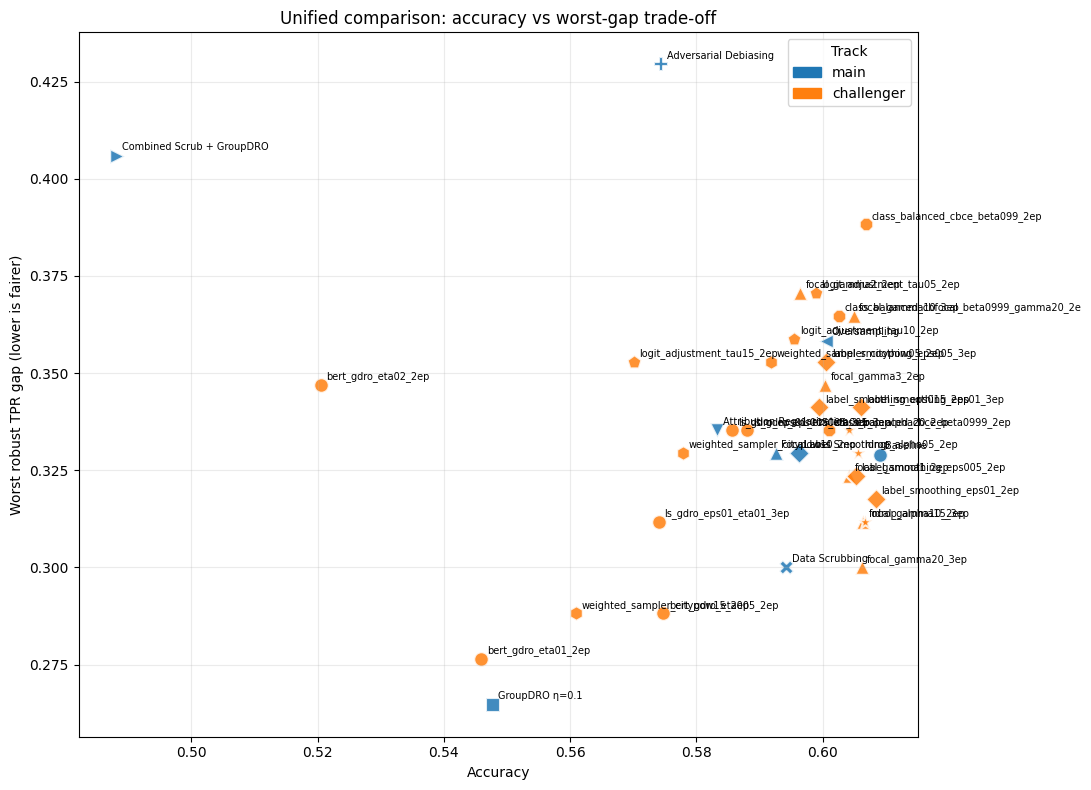

Saved: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/unified_comparison/fig01_accuracy_vs_worst_gap.png and legacy /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/unified_comparison/c71_accuracy_vs_gap.png


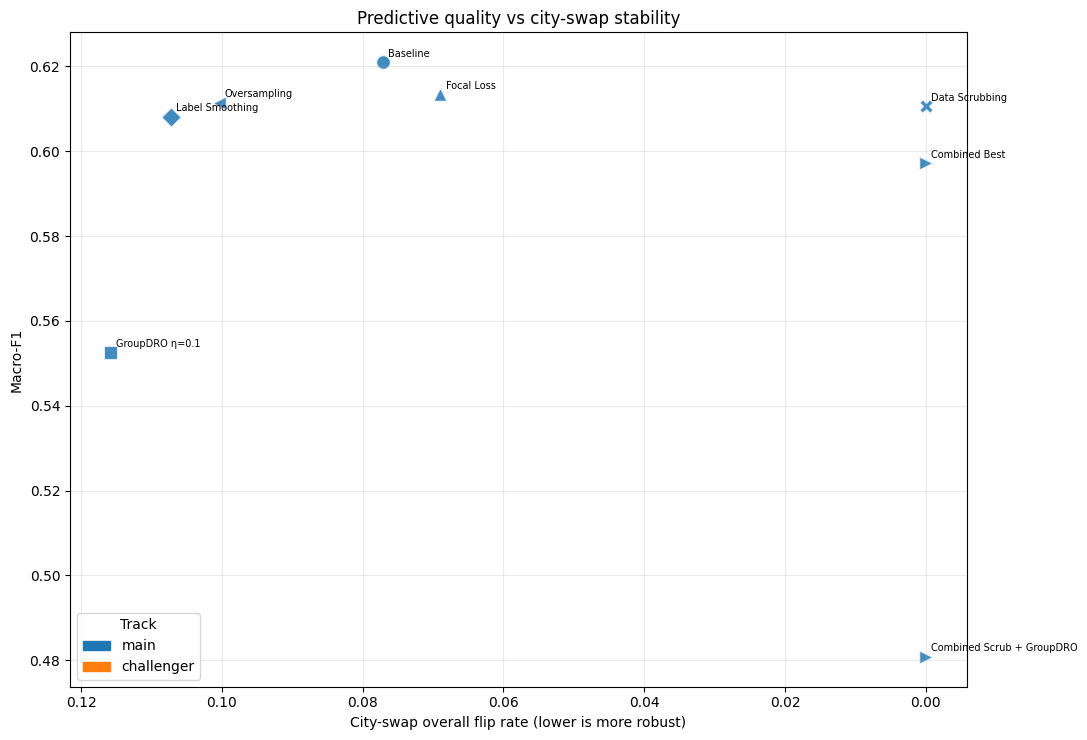

Saved: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/unified_comparison/fig02_macro_f1_vs_city_swap_flip.png


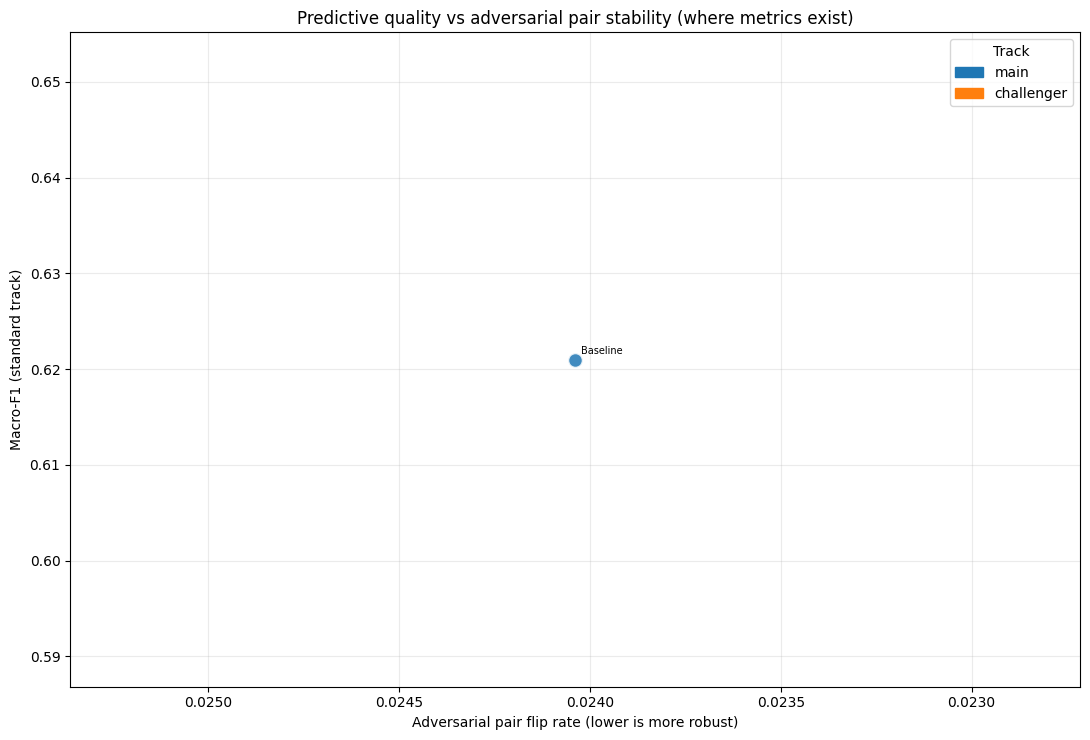

Saved: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/unified_comparison/fig04_macro_f1_vs_adversarial_pair_flip.png


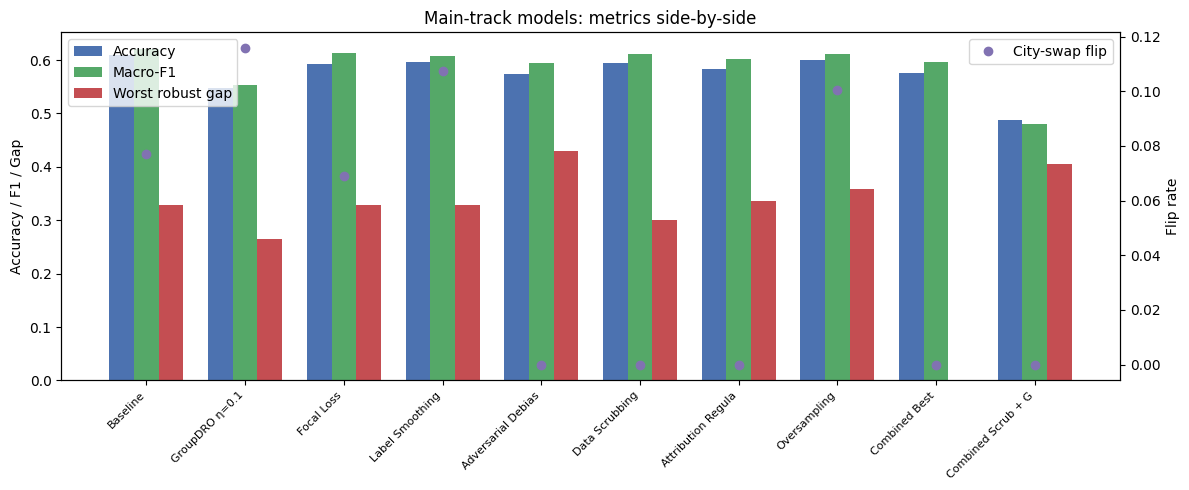

Saved: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/unified_comparison/fig03_main_models_three_metrics.png


In [11]:
if plt is None or mpatches is None:
    print("matplotlib not installed; skipping plots")
else:
    colors = {"main": "#1f77b4", "challenger": "#ff7f0e"}
    markers = {
        "baseline": "o",
        "groupdro": "s",
        "focal": "^",
        "label_smoothing": "D",
        "adversarial": "P",
        "scrubbing": "X",
        "attr_reg": "v",
        "oversampling": "<",
        "combined": ">",
        "weighted_sampler": "h",
        "rdrop": "*",
        "class_balanced": "8",
        "logit_adjustment": "p",
        "other": "o",
    }

    plot_df = unified_df.dropna(subset=["accuracy", "worst_gap"]).copy()
    if plot_df.empty:
        print("No rows with both accuracy and worst_gap available")
    else:
        fig, ax = plt.subplots(figsize=(11, 8))
        for _, row in plot_df.iterrows():
            ax.scatter(
                row["accuracy"],
                row["worst_gap"],
                c=colors.get(row["track"], "gray"),
                marker=markers.get(row["family_group"], "o"),
                s=110,
                alpha=0.85,
                edgecolors='white',
                linewidths=1.5,
            )
            label = row["display_name"] if row["track"] == "main" else row["model_name"]
            ax.annotate(str(label)[:42], (row["accuracy"], row["worst_gap"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
        ax.set_xlabel("Accuracy")
        ax.set_ylabel("Worst robust TPR gap (lower is fairer)")
        ax.set_title("Unified comparison: accuracy vs worst-gap trade-off")
        ax.grid(alpha=0.25)
        handles = [mpatches.Patch(color=colors[k], label=k) for k in colors]
        ax.legend(handles=handles, title="Track")
        plt.tight_layout()
        plt.savefig(FIG_ACC_GAP, dpi=150, bbox_inches='tight')
        plt.savefig(PLOT_LEGACY, dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved:", FIG_ACC_GAP, "and legacy", PLOT_LEGACY)

    flip_df = unified_df.dropna(subset=["macro_f1", "overall_flip_rate"]).copy()
    if not flip_df.empty:
        fig, ax = plt.subplots(figsize=(11, 7.5))
        for _, row in flip_df.iterrows():
            ax.scatter(
                row["overall_flip_rate"],
                row["macro_f1"],
                c=colors.get(row["track"], "gray"),
                marker=markers.get(row["family_group"], "o"),
                s=110,
                alpha=0.85,
                edgecolors='white',
                linewidths=1.5,
            )
            label = row["display_name"] if row["track"] == "main" else row["model_name"]
            ax.annotate(str(label)[:42], (row["overall_flip_rate"], row["macro_f1"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
        ax.set_xlabel("City-swap overall flip rate (lower is more robust)")
        ax.set_ylabel("Macro-F1")
        ax.set_title("Predictive quality vs city-swap stability")
        ax.grid(alpha=0.25)
        ax.invert_xaxis()
        handles = [mpatches.Patch(color=colors[k], label=k) for k in colors]
        ax.legend(handles=handles, title="Track")
        plt.tight_layout()
        plt.savefig(FIG_F1_FLIP, dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved:", FIG_F1_FLIP)

    adv_df = unified_df.dropna(subset=["macro_f1", "adversarial_pair_flip_rate"]).copy()
    if not adv_df.empty:
        fig, ax = plt.subplots(figsize=(11, 7.5))
        for _, row in adv_df.iterrows():
            ax.scatter(
                row["adversarial_pair_flip_rate"],
                row["macro_f1"],
                c=colors.get(row["track"], "gray"),
                marker=markers.get(row["family_group"], "o"),
                s=110,
                alpha=0.85,
                edgecolors='white',
                linewidths=1.5,
            )
            label = row["display_name"] if row["track"] == "main" else row["model_name"]
            ax.annotate(str(label)[:42], (row["adversarial_pair_flip_rate"], row["macro_f1"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
        ax.set_xlabel("Adversarial pair flip rate (lower is more robust)")
        ax.set_ylabel("Macro-F1 (standard track)")
        ax.set_title("Predictive quality vs adversarial pair stability (where metrics exist)")
        ax.grid(alpha=0.25)
        ax.invert_xaxis()
        handles = [mpatches.Patch(color=colors[k], label=k) for k in colors]
        ax.legend(handles=handles, title="Track")
        plt.tight_layout()
        plt.savefig(FIG_F1_ADV_FLIP, dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved:", FIG_F1_ADV_FLIP)

    if len(main_u) > 0:
        m = main_u.dropna(subset=["accuracy", "macro_f1", "worst_gap"], how="all").copy()
        if len(m):
            idx = np.arange(len(m))
            width = 0.25
            fig, ax = plt.subplots(figsize=(12, 5))
            a = m["accuracy"].fillna(0).values
            f1 = m["macro_f1"].fillna(0).values
            g = m["worst_gap"].fillna(0).values
            fl = m["overall_flip_rate"].fillna(0).values
            ax.bar(idx - width, a, width, label="Accuracy", color="#4c72b0")
            ax.bar(idx, f1, width, label="Macro-F1", color="#55a868")
            ax.bar(idx + width, g, width, label="Worst robust gap", color="#c44e52")
            ax2 = ax.twinx()
            ax2.plot(idx, fl, color="#8172b2", marker="o", linestyle="", label="City-swap flip")
            ax2.set_ylabel("Flip rate")
            ax.set_xticks(idx)
            ax.set_xticklabels([str(x)[:18] for x in m["display_name"]], rotation=45, ha="right", fontsize=8)
            ax.set_ylabel("Accuracy / F1 / Gap")
            ax.set_title("Main-track models: metrics side-by-side")
            ax.legend(loc="upper left")
            ax2.legend(loc="upper right")
            plt.tight_layout()
            plt.savefig(FIG_MAIN_BARS, dpi=150, bbox_inches='tight')
            plt.show()
            print("Saved:", FIG_MAIN_BARS)


In [12]:
# Optional: audit vs fairness_error_analysis main snapshot (no new metrics computed)
if FAIRNESS_MAIN_METRICS_CSV.exists():
    fm = pd.read_csv(FAIRNESS_MAIN_METRICS_CSV)
    chk = main_u[["model_name", "accuracy", "macro_f1", "worst_gap", "macro_gap", "overall_flip_rate"]].merge(
        fm,
        on="model_name",
        suffixes=("_unified", "_fairness_csv"),
        how="left",
    )
    for col in ["accuracy", "macro_f1", "worst_gap", "macro_gap", "overall_flip_rate"]:
        c1, c2 = f"{col}_unified", f"{col}_fairness_csv"
        if c1 in chk.columns and c2 in chk.columns:
            chk[f"delta_{col}"] = pd.to_numeric(chk[c1], errors="coerce") - pd.to_numeric(chk[c2], errors="coerce")
    chk.to_csv(OUTPUT_DIR / "07_main_track_reconciliation_vs_fairness_snapshot.csv", index=False)
    display(chk.head(12))
else:
    print("No fairness snapshot at", FAIRNESS_MAIN_METRICS_CSV)


,model_name,accuracy_unified,macro_f1_unified,worst_gap_unified,macro_gap_unified,overall_flip_rate_unified,display_name,accuracy_fairness_csv,macro_f1_fairness_csv,worst_gap_fairness_csv,macro_gap_fairness_csv,overall_flip_rate_fairness_csv,delta_accuracy,delta_macro_f1,delta_worst_gap,delta_macro_gap,delta_overall_flip_rate
0,bert_9classes_final,0.609000,0.621000,0.329000,0.116000,0.077132,Baseline,0.609000,0.621000,0.329000,0.116000,0.077132,0.0,0.0,0.000000e+00,0.000000e+00,5.551115e-17
1,bert_gdro_eta01_2ep,0.547731,0.552506,0.264706,0.112955,0.115789,GroupDRO η=0.1,0.547731,0.552506,0.264706,0.112955,0.115789,0.0,0.0,0.000000e+00,0.000000e+00,2.775558e-17
2,bert_focal_loss,0.592559,0.613432,0.329412,0.135682,0.068966,Focal Loss,0.592559,0.613432,0.329412,0.135682,0.068966,0.0,0.0,0.000000e+00,0.000000e+00,1.387779e-17
3,bert_label_smoothing,0.596189,0.608055,0.329412,0.139537,0.107260,Label Smoothing,0.596189,0.608055,0.329412,0.139537,0.107260,0.0,0.0,0.000000e+00,0.000000e+00,1.387779e-17
4,bert_adversarial,0.574410,0.594231,0.429412,0.131834,NaN,Adversarial Debiasing,0.574410,0.594231,0.429412,0.131834,NaN,0.0,0.0,0.000000e+00,5.551115e-17,NaN
5,bert_scrubbing,0.594192,0.610567,0.300000,0.112077,0.000000,Data Scrubbing,0.594192,0.610567,0.300000,0.112077,0.000000,0.0,0.0,5.551115e-17,5.551115e-17,0.000000e+00
6,bert_attr_reg,0.583303,0.601165,0.335294,0.116298,NaN,Attribution Regularization,0.583303,0.601165,0.335294,0.116298,NaN,0.0,0.0,5.551115e-17,4.163336e-17,NaN
7,bert_oversample_only,0.600544,0.611463,0.358333,0.134891,0.100363,Oversampling,0.600544,0.611463,0.358333,0.134891,0.100363,0.0,0.0,0.000000e+00,2.775558e-17,8.326673e-17
8,combined_scrubbing_groupdro,0.576407,0.597117,NaN,NaN,0.000000,Combined Best,0.576407,0.597117,NaN,NaN,0.000000,0.0,0.0,NaN,NaN,0.000000e+00
9,bert_debiased_combo,0.488203,0.480776,0.405882,0.137764,0.000000,Combined Scrub + GroupDRO,0.488203,0.480776,0.405882,0.137764,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00


## Key takeaways (paper)

- **Standard fairness + quality:** See `04_ranking_picks_by_scope.csv` (`best_macro_f1`, `best_accuracy`). Challenger runs often compete with main checkpoints on F1; always read **together** with robust gap and robustness axes.
- **Fairst on robust TPR gaps:** Rows `fairest_worst_robust_gap` / `fairest_macro_robust_gap` in the same file (lower gap is better under your robust gap definition).
- **City-swap robustness:** `most_robust_city_swap_flip` uses **saved** flip rates (`city_swap_all_models.json` plus merged challenger `c10` CSV when present). One **location counterfactual** axis among several; zero-flip entries are **protocol-dependent**—cite the artifact.
- **Adversarial eval:** `most_robust_adversarial_pair_flip` ranks rows using `adversarial_model_eval/<model_run_id>/metrics.json` when present (pair flip rate on minimal edits). Missing folders simply yield NaN in the unified table—no blocking error.
- **English transfer:** `best_english_transfer_test_macro_f1` uses `english_transfer_eval/<model_run_id>/metrics.json` (`english_test` split). Optional slice columns (`english_base_eval_slice_*`) are merged for thesis tables when logged.
- **Trade-offs:** `05_pareto_triobjective_balance.csv` is an equal-weight blend of F1, inverted worst-gap, and inverted **city-swap** flip. When adversarial + English columns are populated for multiple models, `05_pareto_extended_benchmark_balance.csv` adds those axes (five-way equal weight). Figures `fig01`–`fig04` in `figures/unified_comparison/` show 2-D structure.
- **Per family:** `06_family_best_per_metric.csv` (same row set as `c71_family_summary.csv`) lists best-on-F1, best-on-gap, best-on-city-flip, and (when available) best-on-adversarial-pair-flip and English-transfer F1 within each **track × family** block.

Re-run after upstream JSON/CSV refresh; this notebook does not train or re-score models.
